# Cotton Disease Final Model (Leakage-Safe + Bias-Aware + Curriculum Tuning)

This notebook trains a cotton disease classifier with strict controls for data leakage, overfitting, and evaluation bias, then applies targeted curriculum upgrades to push accuracy beyond the current baseline.

## Dataset Summary
- Classes: Bacterial Blight, Curl Virus, Healthy Leaf, Herbicide Growth Damage, Leaf Hopper Jassids, Leaf Redding, Leaf Variegation
- Raw source currently has one folder per class (no predefined train/val/test)
- This notebook rebuilds a leakage-safe grouped split before any training

## Reliability Goals
1. Remove exact duplicate leakage across train/val/test using SHA256 audits
2. Keep source groups together so near-duplicate variants do not cross splits
3. Drop ambiguous cross-class duplicate hashes to reduce label noise
4. Use stronger regularization and curriculum fine-tuning to reduce overfitting
5. Select inference strategy only on validation (single, TTA, optional ensemble) before one untouched final test pass

## Training/Evaluation Plan
1. Runtime initialization
2. Paths and hyperparameters
3. Rebuild leakage-safe split + run leakage audits
4. Build staged tf.data pipelines and class weights from train split only
5. Build and compile EfficientNetV2 transfer-learning model
6. Configure callbacks/checkpoint strategy
7. Train head with strong augmentation
8. Fine-tune deeper layers with hard-class boosting and lighter augmentation
9. Optional progressive-resize low-LR stage
10. Plot learning curves and generalization gap
11. Run validation diagnostics and choose final inference strategy
12. Run one final untouched test evaluation + save artifacts
13. Optional single-image inference demo

### Runtime Initialization

**Working:** Imports required libraries, seeds randomness, and configures GPU mixed precision when available.

**Function:** Creates a reproducible, hardware-aware runtime baseline for consistent training behavior.

In [1]:
import os
import re
import json
import random
import shutil
import hashlib
import warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from keras import layers, callbacks
from keras.applications.efficientnet_v2 import (
    EfficientNetV2B0,
    EfficientNetV2S,
    EfficientNetV2M,
    preprocess_input,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score,
    top_k_accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

REQUIRE_GPU = True
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    from keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    DEVICE = f"GPU ({gpus[0].name}) with mixed precision"
else:
    DEVICE = "CPU"
    if REQUIRE_GPU:
        raise RuntimeError("GPU not detected. Open a GPU-enabled kernel/environment before training.")

print(f"TensorFlow: {tf.__version__}")
print(f"Keras     : {keras.__version__}")
print(f"Device    : {DEVICE}")

I0000 00:00:1775375901.619462   18690 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775375901.685461   18690 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775375903.176945   18690 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Keras     : 3.13.2
Device    : GPU (/physical_device:GPU:0) with mixed precision


### Paths and Hyperparameters

**Working:** Defines dataset/model paths, split policy, and training hyperparameters for optimization and regularization.

**Function:** Centralizes experiment controls so leakage policy, overfitting guards, and evaluation settings are explicit and easy to tune.

In [2]:
from pathlib import Path


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / "Datasets").exists() and (candidate / "saved_models").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing both 'Datasets' and 'saved_models'. "
        f"Current working directory: {cwd}"
    )

BASE_DIR = _find_project_root()
DATASETS_DIR = BASE_DIR / "Datasets"

RAW_SOURCE_DIR = DATASETS_DIR / "cotton Dataset"
if not RAW_SOURCE_DIR.exists():
    raise FileNotFoundError(f"Missing raw dataset directory: {RAW_SOURCE_DIR}")

SOURCE_DIR = DATASETS_DIR / "cotton Dataset_clean_noleak"
TRAIN_DIR = SOURCE_DIR / "train"
VAL_DIR = SOURCE_DIR / "val"
TEST_DIR = SOURCE_DIR / "test"

CLEAN_SPLIT_RATIOS = (0.70, 0.15, 0.15)
REBUILD_CLEAN_SPLIT = True
DROP_AMBIGUOUS_CROSS_CLASS_HASHES = True

MODELS_DIR = BASE_DIR / "saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE_HEAD = (224, 224)
IMG_SIZE_FINE = (224, 224)
IMG_SIZE_PROGRESSIVE = (300, 300)
ENABLE_PROGRESSIVE_RESIZE = True
MODEL_INPUT_SHAPE = (None, None, 3)

BATCH_SIZE = 24 if gpus else 12
AUTOTUNE = tf.data.AUTOTUNE

BACKBONE_NAME = "efficientnetv2s"  # options: efficientnetv2b0, efficientnetv2s, efficientnetv2m
BACKBONE_TAG = BACKBONE_NAME.lower()

EPOCHS_HEAD = 10
EPOCHS_FINE = 15
EPOCHS_RESIZE = 5
LR_HEAD = 2e-4
LR_FINE = 8e-6
LR_RESIZE = 5e-6

FINE_TUNE_RATIO = 0.35
MIN_UNFREEZE_LAYERS = 120
WEIGHT_DECAY = 2e-4
DROPOUT_RATE = 0.45
LABEL_SMOOTHING = 0.08
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

MIXUP_ALPHA_HEAD = 0.20
MIXUP_ALPHA_FINE = 0.08
MIXUP_ALPHA_RESIZE = 0.00
AUGMENT_POLICY_HEAD = "strong"
AUGMENT_POLICY_FINE = "light"
AUGMENT_POLICY_RESIZE = "light"

HARD_TOP_K = 3
HARD_CLASS_BOOST = 1.25

ENABLE_BACKBONE_ENSEMBLE = True
ENSEMBLE_BACKBONE_PATHS = [
    MODELS_DIR / "cotton_best_efficientnetv2b0.keras",
]

TTA_ROUNDS = 3
BOOTSTRAP_ROUNDS = 1000
CONFIDENCE_LEVEL = 0.95

PHASH_SIZE = 8
PHASH_HIGHFREQ_FACTOR = 4
PHASH_HAMMING_THRESHOLD = 8

print(f"Project root           : {BASE_DIR}")
print(f"Datasets root          : {DATASETS_DIR}")
print(f"Raw dataset root      : {RAW_SOURCE_DIR}")
print(f"Leakage-safe root     : {SOURCE_DIR}")
print(f"Image size (head)     : {IMG_SIZE_HEAD}")
print(f"Image size (fine)     : {IMG_SIZE_FINE}")
print(f"Image size (resize)   : {IMG_SIZE_PROGRESSIVE} (enabled={ENABLE_PROGRESSIVE_RESIZE})")
print(f"Batch size            : {BATCH_SIZE}")
print(f"Backbone              : {BACKBONE_NAME}")
print(f"Training epochs       : head({EPOCHS_HEAD}) + fine({EPOCHS_FINE}) + resize({EPOCHS_RESIZE})")
print(f"Fine-tune strategy    : top {int(FINE_TUNE_RATIO * 100)}% or at least {MIN_UNFREEZE_LAYERS} layers")
print(f"Loss                  : focal(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}) + label_smoothing={LABEL_SMOOTHING}")
print(f"MixUp alpha schedule  : head={MIXUP_ALPHA_HEAD}, fine={MIXUP_ALPHA_FINE}, resize={MIXUP_ALPHA_RESIZE}")
print(f"Aug policy schedule   : head={AUGMENT_POLICY_HEAD}, fine={AUGMENT_POLICY_FINE}, resize={AUGMENT_POLICY_RESIZE}")
print(f"Hard-class boost      : top_k={HARD_TOP_K}, factor={HARD_CLASS_BOOST}")
print(f"Backbone ensemble     : enabled={ENABLE_BACKBONE_ENSEMBLE}")
print(f"Drop ambiguous hashes : {DROP_AMBIGUOUS_CROSS_CLASS_HASHES}")
print(f"TTA rounds            : {TTA_ROUNDS}")

Project root           : /home/mohitmehta60/Desktop/Project/Minor Project
Datasets root          : /home/mohitmehta60/Desktop/Project/Minor Project/Datasets
Raw dataset root      : /home/mohitmehta60/Desktop/Project/Minor Project/Datasets/cotton Dataset
Leakage-safe root     : /home/mohitmehta60/Desktop/Project/Minor Project/Datasets/cotton Dataset_clean_noleak
Image size (head)     : (224, 224)
Image size (fine)     : (224, 224)
Image size (resize)   : (300, 300) (enabled=True)
Batch size            : 24
Backbone              : efficientnetv2s
Training epochs       : head(10) + fine(15) + resize(5)
Fine-tune strategy    : top 35% or at least 120 layers
Loss                  : focal(alpha=0.25, gamma=2.0) + label_smoothing=0.08
MixUp alpha schedule  : head=0.2, fine=0.08, resize=0.0
Aug policy schedule   : head=strong, fine=light, resize=light
Hard-class boost      : top_k=3, factor=1.25
Backbone ensemble     : enabled=True
Drop ambiguous hashes : True
TTA rounds            : 3


### Leakage-Safe Split Builder

**Working:** Rebuilds train/val/test from raw folders using SHA256 deduplication, source-group-aware assignment, pHash near-duplicate filtering, and overlap audits.

**Function:** Eliminates data leakage (hash/group/path overlap) and removes ambiguous cross-class duplicate content before model training.

Raw dataset audit (images per class):


,class_name,raw_images
0,Bacterial Blight,1000
1,Curl Virus,1000
2,Healthy Leaf,1000
3,Herbicide Growth Damage,1000
4,Leaf Hopper Jassids,1000
5,Leaf Redding,1000
6,Leaf Variegation,1000


Raw extension audit:
  .jpg: 7000


I0000 00:00:1775375908.481549   18690 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Split rebuild summary:


...

pHash near-duplicate audit:


,class_name,kept_after_phash,near_dup_removed,phash_failures
0,Bacterial Blight,684,210,0
1,Curl Virus,767,166,0
2,Healthy Leaf,654,245,0
3,Herbicide Growth Damage,674,225,0
4,Leaf Hopper Jassids,653,215,0
5,Leaf Redding,825,134,0
6,Leaf Variegation,450,324,0


Saved split manifest: /home/mohitmehta60/Desktop/Project/Minor Project/Datasets/cotton Dataset_clean_noleak/split_manifest.csv
Ambiguous cross-class hashes detected: 3
Leakage audit:
  hashes appearing in multiple splits : 0
  groups appearing in multiple splits : 0
  paths appearing in multiple splits  : 0
Leakage-safe split distribution:


,class_name,train,val,test,total
0,Bacterial Blight,479,103,102,684
1,Curl Virus,537,115,115,767
2,Healthy Leaf,458,98,98,654
3,Herbicide Growth Damage,472,101,101,674
4,Leaf Hopper Jassids,457,98,98,653
5,Leaf Redding,577,124,124,825
6,Leaf Variegation,315,68,67,450


Classes missing by split: {'train': [], 'val': [], 'test': []}
Total leakage-safe images: 4707


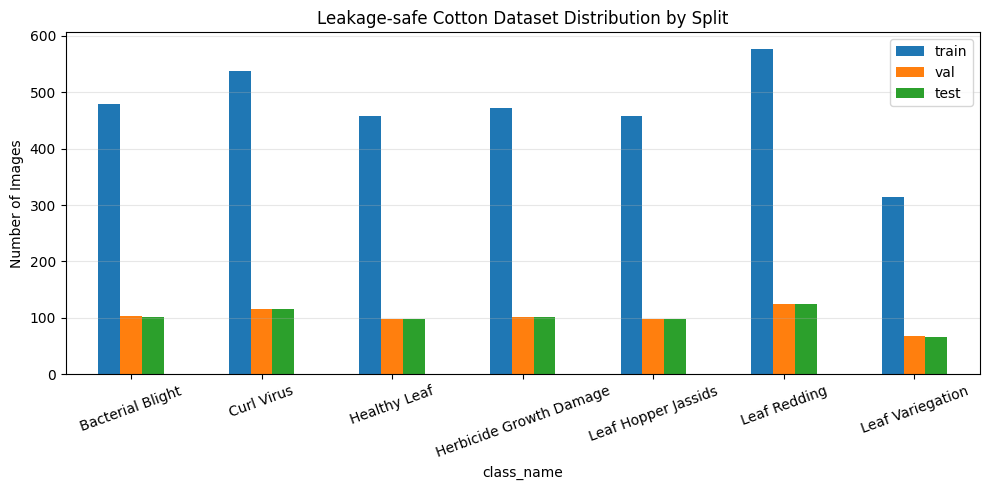

In [3]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

try:
    RESAMPLE_BICUBIC = Image.Resampling.BICUBIC
except AttributeError:
    RESAMPLE_BICUBIC = Image.BICUBIC

def list_images(root_dir: Path) -> list[Path]:
    return sorted([p for p in root_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS])

def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def phash64(path: Path, hash_size: int = 8, highfreq_factor: int = 4) -> int:
    img_size = hash_size * highfreq_factor
    with Image.open(path) as img:
        arr = np.asarray(
            img.convert('L').resize((img_size, img_size), resample=RESAMPLE_BICUBIC),
            dtype=np.float32,
        )

    dct_rows = tf.signal.dct(arr, type=2, norm='ortho')
    dct_2d = tf.signal.dct(tf.transpose(dct_rows), type=2, norm='ortho')
    dct_2d = tf.transpose(dct_2d).numpy()

    lowfreq = dct_2d[:hash_size, :hash_size]
    med = np.median(lowfreq[1:, 1:])
    bits = (lowfreq > med).astype(np.uint8).flatten()

    hash_int = 0
    for bit in bits:
        hash_int = (hash_int << 1) | int(bit)
    return hash_int

def hamming_distance_int(a: int, b: int) -> int:
    return int((a ^ b).bit_count())

def source_group_id(path: Path) -> str:
    match = re.search(r'(\d+)$', path.stem)
    if match:
        return match.group(1)
    stem = re.sub(r'(_aug\d+|_flip\d+|_rot\d+|_copy\d+)$', '', path.stem, flags=re.IGNORECASE)
    return stem

def assign_groups_by_image_targets(grouped: dict[str, list[dict]], seed: int) -> dict[str, list[str]]:
    rng = random.Random(seed)
    group_keys = list(grouped.keys())
    rng.shuffle(group_keys)
    group_keys = sorted(group_keys, key=lambda k: len(grouped[k]), reverse=True)

    split_names = ['train', 'val', 'test']
    target_ratios = dict(zip(split_names, CLEAN_SPLIT_RATIOS))
    total_images = sum(len(grouped[k]) for k in group_keys)
    targets = {s: total_images * target_ratios[s] for s in split_names}

    assigned = {s: [] for s in split_names}
    counts = {s: 0 for s in split_names}

    if len(group_keys) >= 3:
        for split_name in split_names:
            key = group_keys.pop(0)
            assigned[split_name].append(key)
            counts[split_name] += len(grouped[key])

    for key in group_keys:
        deficits = {s: targets[s] - counts[s] for s in split_names}
        best_split = max(split_names, key=lambda s: (deficits[s], -counts[s]))
        assigned[best_split].append(key)
        counts[best_split] += len(grouped[key])

    return assigned

def link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    try:
        os.link(src, dst)
    except OSError:
        shutil.copy2(src, dst)

def count_images_by_class(split_dir: Path) -> pd.DataFrame:
    rows = []
    for cls_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
        n = len([p for p in cls_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS])
        rows.append({'class_name': cls_dir.name, 'count': n})
    return pd.DataFrame(rows).sort_values('class_name').reset_index(drop=True)

raw_class_dirs = sorted([d for d in RAW_SOURCE_DIR.iterdir() if d.is_dir()])
if not raw_class_dirs:
    raise RuntimeError(f'No class folders found inside raw dataset directory: {RAW_SOURCE_DIR}')

raw_records = []
for cls_dir in raw_class_dirs:
    for p in list_images(cls_dir):
        raw_records.append({
            'class_name': cls_dir.name,
            'src_path': str(p),
            'sha256': file_sha256(p),
            'group_id': source_group_id(p),
        })

raw_df = pd.DataFrame(raw_records)
if raw_df.empty:
    raise RuntimeError('No images found in raw cotton dataset folders.')

class_names_raw = sorted(raw_df['class_name'].unique().tolist())
ext_counts = Counter(Path(p).suffix.lower() for p in raw_df['src_path'].tolist())

print('Raw dataset audit (images per class):')
display(raw_df.groupby('class_name').size().reset_index(name='raw_images').sort_values('class_name').reset_index(drop=True))
print('Raw extension audit:')
for ext, count in sorted(ext_counts.items(), key=lambda kv: kv[1], reverse=True):
    print(f'  {ext}: {count}')

hash_class_counts = raw_df.groupby('sha256')['class_name'].nunique()
ambiguous_hashes = set(hash_class_counts[hash_class_counts > 1].index)
ambiguous_removed_by_class = (
    raw_df[raw_df['sha256'].isin(ambiguous_hashes)].groupby('class_name').size().to_dict()
 )

if DROP_AMBIGUOUS_CROSS_CLASS_HASHES and ambiguous_hashes:
    clean_df = raw_df[~raw_df['sha256'].isin(ambiguous_hashes)].copy()
else:
    clean_df = raw_df.copy()

clean_df = (
    clean_df
    .sort_values('src_path')
    .drop_duplicates(subset=['class_name', 'sha256'], keep='first')
    .reset_index(drop=True)
 )

if clean_df.empty:
    raise RuntimeError('No images left after duplicate cleaning. Check cleaning policy.')

filtered_rows = []
phash_stats_rows = []

for cls_name in class_names_raw:
    cls_df = clean_df[clean_df['class_name'] == cls_name].copy()
    if cls_df.empty:
        continue

    kept_phashes = []
    kept_records = []
    near_dup_removed = 0
    phash_failures = 0

    for row in cls_df.sort_values('src_path').to_dict('records'):
        src_path = Path(row['src_path'])
        h64 = None
        try:
            h64 = phash64(src_path, hash_size=PHASH_SIZE, highfreq_factor=PHASH_HIGHFREQ_FACTOR)
            is_near_duplicate = any(
                hamming_distance_int(h64, prev_h64) <= PHASH_HAMMING_THRESHOLD
                for prev_h64 in kept_phashes
            )
        except Exception:
            phash_failures += 1
            is_near_duplicate = False

        if is_near_duplicate:
            near_dup_removed += 1
            continue

        kept_records.append(row)
        if h64 is not None:
            kept_phashes.append(h64)

    filtered_rows.extend(kept_records)
    phash_stats_rows.append({
        'class_name': cls_name,
        'kept_after_phash': len(kept_records),
        'near_dup_removed': near_dup_removed,
        'phash_failures': phash_failures,
    })

clean_df = pd.DataFrame(filtered_rows)
if clean_df.empty:
    raise RuntimeError('No images left after pHash near-duplicate filtering.')

phash_stats_df = pd.DataFrame(phash_stats_rows).sort_values('class_name').reset_index(drop=True)

if REBUILD_CLEAN_SPLIT and SOURCE_DIR.exists():
    shutil.rmtree(SOURCE_DIR)

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

global_hash_split = {}
manifest_rows = []
build_rows = []

for cls_name in class_names_raw:
    cls_df = clean_df[clean_df['class_name'] == cls_name].copy()
    if cls_df.empty:
        raise RuntimeError(f'Class {cls_name} has no images after cleaning.')

    grouped = defaultdict(list)
    for row in cls_df.to_dict('records'):
        grouped[row['group_id']].append(row)

    class_seed = SEED + sum(ord(ch) for ch in cls_name)
    split_groups = assign_groups_by_image_targets(grouped, seed=class_seed)
    preferred_split_by_group = {
        group_id: split_name
        for split_name, group_ids in split_groups.items()
        for group_id in group_ids
    }

    written = {'train': 0, 'val': 0, 'test': 0}
    for group_id, items in grouped.items():
        preferred_split = preferred_split_by_group[group_id]
        safe_group = re.sub(r'[^A-Za-z0-9_-]', '-', str(group_id))

        for row in items:
            src_path = Path(row['src_path'])
            h = row['sha256']

            target_split = global_hash_split.get(h, preferred_split)
            global_hash_split[h] = target_split

            split_root = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}[target_split]
            dst_name = f'g{safe_group}_{src_path.stem}_{h[:8]}{src_path.suffix.lower()}'
            dst_path = split_root / cls_name / dst_name
            link_or_copy(src_path, dst_path)
            written[target_split] += 1

            manifest_rows.append({
                'class_name': cls_name,
                'split': target_split,
                'group_key': f'{cls_name}::{group_id}',
                'sha256': h,
                'src_path': str(src_path),
                'dst_path': str(dst_path),
            })

    build_rows.append({
        'class_name': cls_name,
        'raw_images': int((raw_df['class_name'] == cls_name).sum()),
        'ambiguous_removed': int(ambiguous_removed_by_class.get(cls_name, 0)) if DROP_AMBIGUOUS_CROSS_CLASS_HASHES else 0,
        'clean_images': int((clean_df['class_name'] == cls_name).sum()),
        'source_groups': int(len(grouped)),
        'train': written['train'],
        'val': written['val'],
        'test': written['test'],
    })

build_df = pd.DataFrame(build_rows).sort_values('class_name').reset_index(drop=True)
print('Split rebuild summary:')
display(build_df)

print('pHash near-duplicate audit:')
display(phash_stats_df)

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = SOURCE_DIR / 'split_manifest.csv'
manifest_df.to_csv(manifest_path, index=False)
print(f'Saved split manifest: {manifest_path}')

print(f'Ambiguous cross-class hashes detected: {len(ambiguous_hashes)}')

hash_split_counts = manifest_df.groupby('sha256')['split'].nunique()
group_split_counts = manifest_df.groupby('group_key')['split'].nunique()
path_split_counts = manifest_df.groupby('src_path')['split'].nunique()

leak_by_hash = int((hash_split_counts > 1).sum())
leak_by_group = int((group_split_counts > 1).sum())
leak_by_path = int((path_split_counts > 1).sum())

print('Leakage audit:')
print(f'  hashes appearing in multiple splits : {leak_by_hash}')
print(f'  groups appearing in multiple splits : {leak_by_group}')
print(f'  paths appearing in multiple splits  : {leak_by_path}')

if leak_by_hash + leak_by_group + leak_by_path != 0:
    raise RuntimeError('Leakage still exists after rebuilding split. Check manifest audit.')

train_counts = count_images_by_class(TRAIN_DIR).rename(columns={'count': 'train'})
val_counts = count_images_by_class(VAL_DIR).rename(columns={'count': 'val'})
test_counts = count_images_by_class(TEST_DIR).rename(columns={'count': 'test'})

dist = train_counts.merge(val_counts, on='class_name', how='outer').merge(test_counts, on='class_name', how='outer').fillna(0)
for c in ['train', 'val', 'test']:
    dist[c] = dist[c].astype(int)
dist['total'] = dist['train'] + dist['val'] + dist['test']

print('Leakage-safe split distribution:')
display(dist.sort_values('class_name').reset_index(drop=True))

missing_in_split = {
    split_name: sorted(set(class_names_raw) - set(df['class_name'].tolist()))
    for split_name, df in [('train', train_counts), ('val', val_counts), ('test', test_counts)]
}
print('Classes missing by split:', missing_in_split)
print(f"Total leakage-safe images: {int(dist['total'].sum())}")

ax = dist.set_index('class_name')[['train', 'val', 'test']].plot(kind='bar', figsize=(10, 5))
ax.set_title('Leakage-safe Cotton Dataset Distribution by Split')
ax.set_ylabel('Number of Images')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Staged Dataset Pipeline and Class Weights

**Working:** Builds staged train/val/test tf.data pipelines with scheduled augmentation and MixUp, then computes class weights from the train split only.

**Function:** Supports curriculum training (strong to light augmentation, reduced MixUp, optional higher resolution) while preserving leakage-safe evaluation discipline.

In [4]:
def build_data_augmentation(policy: str = "strong") -> keras.Sequential:
    if policy == "strong":
        return keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomTranslation(0.08, 0.08),
            layers.RandomZoom(0.20),
            layers.RandomContrast(0.20),
            layers.RandomBrightness(0.20),
            layers.GaussianNoise(0.05),
        ], name="data_augmentation_strong")

    if policy == "light":
        return keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomTranslation(0.04, 0.04),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
            layers.RandomBrightness(0.10),
        ], name="data_augmentation_light")

    raise ValueError(f"Unsupported augmentation policy: {policy}")

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def sample_beta_distribution(batch_size: tf.Tensor, alpha: float) -> tf.Tensor:
    gamma_1 = tf.random.gamma(shape=[batch_size], alpha=alpha)
    gamma_2 = tf.random.gamma(shape=[batch_size], alpha=alpha)
    return gamma_1 / (gamma_1 + gamma_2)

def mixup(images, labels, alpha: float):
    if alpha <= 0:
        return images, labels

    batch_size = tf.shape(images)[0]
    index = tf.random.shuffle(tf.range(batch_size))
    lam = sample_beta_distribution(batch_size, alpha)
    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    mixed_images = lam_x * images + (1.0 - lam_x) * tf.gather(images, index)
    mixed_labels = lam_y * labels + (1.0 - lam_y) * tf.gather(labels, index)
    return mixed_images, mixed_labels

def make_datasets(
    image_size: tuple[int, int],
    batch_size: int,
    mixup_alpha: float,
    aug_policy: str,
    class_names_ref: list[str] | None = None,
 ):
    augmentation = build_data_augmentation(aug_policy)

    train_kwargs = dict(
        directory=TRAIN_DIR,
        labels="inferred",
        label_mode="categorical",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=True,
        seed=SEED,
        interpolation="bilinear",
    )
    if class_names_ref is not None:
        train_kwargs["class_names"] = class_names_ref

    train_raw_local = keras.utils.image_dataset_from_directory(**train_kwargs)
    class_names_local = list(train_raw_local.class_names)

    if class_names_ref is not None and class_names_local != list(class_names_ref):
        raise RuntimeError("Class order drift detected while rebuilding staged datasets.")

    val_raw_local = keras.utils.image_dataset_from_directory(
        VAL_DIR,
        labels="inferred",
        class_names=class_names_local,
        label_mode="categorical",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False,
        interpolation="bilinear",
    )

    test_raw_local = keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        class_names=class_names_local,
        label_mode="categorical",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False,
        interpolation="bilinear",
    )

    def augment_and_preprocess(image, label):
        image = augmentation(image, training=True)
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)
        return image, label

    train_ds_local = train_raw_local.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    train_ds_local = train_ds_local.map(augment_and_preprocess, num_parallel_calls=AUTOTUNE)
    if mixup_alpha > 0:
        train_ds_local = train_ds_local.map(
            lambda x, y: mixup(x, y, alpha=mixup_alpha),
            num_parallel_calls=AUTOTUNE,
        )
    train_ds_local = train_ds_local.prefetch(AUTOTUNE)

    val_ds_local = val_raw_local.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
    test_ds_local = test_raw_local.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

    train_steps_local = int(tf.data.experimental.cardinality(train_ds_local).numpy())
    if train_steps_local <= 0:
        train_image_count_local = int(
            sum(1 for p in TRAIN_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)
        )
        train_steps_local = max(1, int(np.ceil(train_image_count_local / batch_size)))

    return {
        "train_raw": train_raw_local,
        "val_raw": val_raw_local,
        "test_raw": test_raw_local,
        "train_ds": train_ds_local,
        "val_ds": val_ds_local,
        "test_ds": test_ds_local,
        "class_names": class_names_local,
        "augmentation": augmentation,
        "train_steps": train_steps_local,
        "image_size": image_size,
        "mixup_alpha": mixup_alpha,
        "aug_policy": aug_policy,
    }

stage_head = make_datasets(
    image_size=IMG_SIZE_HEAD,
    batch_size=BATCH_SIZE,
    mixup_alpha=MIXUP_ALPHA_HEAD,
    aug_policy=AUGMENT_POLICY_HEAD,
 )

train_raw = stage_head["train_raw"]
val_raw = stage_head["val_raw"]
test_raw = stage_head["test_raw"]
train_ds = stage_head["train_ds"]
val_ds = stage_head["val_ds"]
test_ds = stage_head["test_ds"]
class_names = stage_head["class_names"]
num_classes = len(class_names)
data_augmentation = stage_head["augmentation"]
train_steps = stage_head["train_steps"]

ACTIVE_IMAGE_SIZE = stage_head["image_size"]
ACTIVE_MIXUP_ALPHA = stage_head["mixup_alpha"]
ACTIVE_AUG_POLICY = stage_head["aug_policy"]

train_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in train_raw], axis=0)
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels,
 )
class_weight_values = np.asarray(class_weight_values, dtype=np.float32)
class_weight_values = np.clip(class_weight_values, 0.6, 2.5)
class_weights = {i: float(w) for i, w in enumerate(class_weight_values)}

train_image_count = int(sum(1 for p in TRAIN_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS))
val_image_count = int(sum(1 for p in VAL_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS))
test_image_count = int(sum(1 for p in TEST_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS))

print("Classes:", class_names)
print("Num classes:", num_classes)
print("Image counts -> train:", train_image_count, ", val:", val_image_count, ", test:", test_image_count)
print("Stage-1 image size:", ACTIVE_IMAGE_SIZE)
print("Stage-1 augmentation:", ACTIVE_AUG_POLICY)
print("Stage-1 MixUp alpha:", ACTIVE_MIXUP_ALPHA)
print("Clipped class weights:", class_weights)
print("Train steps/epoch:", train_steps)

Found 3295 files belonging to 7 classes.
Found 707 files belonging to 7 classes.
Found 705 files belonging to 7 classes.
Classes: ['Bacterial Blight', 'Curl Virus', 'Healthy Leaf', 'Herbicide Growth Damage', 'Leaf Hopper Jassids', 'Leaf Redding', 'Leaf Variegation']
Num classes: 7
Image counts -> train: 3295 , val: 707 , test: 705
Stage-1 image size: (224, 224)
Stage-1 augmentation: strong
Stage-1 MixUp alpha: 0.2
Clipped class weights: {0: 0.9827020764350891, 1: 0.8765628933906555, 2: 1.0277605056762695, 3: 0.9972760081291199, 4: 1.030009388923645, 5: 0.8157960176467896, 6: 1.4943311214447021}
Train steps/epoch: 138


### Model Definition and Compile

**Working:** Builds an EfficientNetV2 transfer-learning model with focal loss, AdamW, dropout, and weight decay.

**Function:** Creates a regularized classifier architecture intended to improve minority-class learning while limiting overfitting.

In [5]:
print("STEP 1/13: Build and compile model")

BACKBONE_FACTORY = {
    "efficientnetv2b0": EfficientNetV2B0,
    "efficientnetv2s": EfficientNetV2S,
    "efficientnetv2m": EfficientNetV2M,
}

if BACKBONE_NAME not in BACKBONE_FACTORY:
    raise ValueError(f"Unsupported BACKBONE_NAME: {BACKBONE_NAME}")

def focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.0):
    cce = keras.losses.CategoricalCrossentropy(
        label_smoothing=label_smoothing,
        reduction=keras.losses.Reduction.NONE,
    )

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, keras.backend.epsilon(), 1.0 - keras.backend.epsilon())
        ce = cce(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        return alpha * tf.pow(1.0 - p_t, gamma) * ce

    return loss

def build_model(
    num_classes: int,
    input_shape=MODEL_INPUT_SHAPE,
    backbone_name: str = BACKBONE_NAME,
 ):
    backbone_fn = BACKBONE_FACTORY[backbone_name]
    base_model = backbone_fn(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape, name="input_image")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        dtype="float32",
    )(x)

    model = keras.Model(inputs, outputs, name=f"cotton_{backbone_name}")
    return model, base_model

def compile_model(model, learning_rate: float):
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=WEIGHT_DECAY,
            clipnorm=1.0,
        ),
        loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING),
        metrics=[
            "accuracy",
            keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc"),
        ],
    )

model, base_model = build_model(
    num_classes=num_classes,
    input_shape=MODEL_INPUT_SHAPE,
    backbone_name=BACKBONE_NAME,
 )
compile_model(model, learning_rate=LR_HEAD)

print(f"Backbone: {BACKBONE_NAME}")
print(f"Model input shape: {MODEL_INPUT_SHAPE}")
print(f"Train steps/epoch: {train_steps}")
print("Using focal loss + AdamW + class weights + staged curriculum")
model.summary()

STEP 1/13: Build and compile model
Backbone: efficientnetv2s
Model input shape: (None, None, 3)
Train steps/epoch: 138
Using focal loss + AdamW + class weights + staged curriculum


Model: "cotton_efficientnetv2s"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, None, None,     │    20,331,360 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,345,447 (77.61 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 20,333,920 (77.57 MB)

### Callback Strategy

**Working:** Configures checkpointing, early stopping, adaptive learning-rate reduction, and NaN termination safeguards.

**Function:** Controls over-training and stabilizes convergence while preserving the best validation checkpoint.

In [6]:
print("STEP 2/13: Configure callbacks and checkpoint")

CKPT_PATH = MODELS_DIR / f"cotton_best_{BACKBONE_TAG}.keras"

cb_list = [
    callbacks.ModelCheckpoint(
        filepath=str(CKPT_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.4,
        patience=2,
        cooldown=1,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.TerminateOnNaN(),
]

print("Checkpoint path:", CKPT_PATH)

STEP 2/13: Configure callbacks and checkpoint
Checkpoint path: /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras


### Phase 1 Training (Strong Augmentation)

**Working:** Trains only the classification head with strong augmentation and stronger MixUp while keeping the pretrained backbone frozen.

**Function:** Builds robust coarse class boundaries before deeper adaptation, reducing early memorization risk.

In [7]:
print("STEP 3/13: Phase 1 - train classification head (backbone frozen)")
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=cb_list,
    class_weight=class_weights,
    verbose=1,
 )

STEP 3/13: Phase 1 - train classification head (backbone frozen)
Epoch 1/10


E0000 00:00:1775376068.927272   18690 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_5}}
E0000 00:00:1775376069.076284   18690 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1775376099.789787   19040 shuffle_dataset_op.cc:453] ShuffleDatasetV3:22: Filling up shuffle buffer (this may take a while): 60

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.2185 - loss: 0.5623 - top2_acc: 0.3809
Epoch 1: val_loss improved from None to 0.22378, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 1: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 154s 743ms/step - accuracy: 0.2668 - loss: 0.4907 - top2_acc: 0.4422 - val_accuracy: 0.5502 - val_loss: 0.2238 - val_top2_acc: 0.7355 - learning_rate: 2.0000e-04
Epoch 2/10


I0000 00:00:1775376232.671425   19040 shuffle_dataset_op.cc:453] ShuffleDatasetV3:22: Filling up shuffle buffer (this may take a while): 64 of 2048
I0000 00:00:1775376245.338847   19040 shuffle_dataset_op.cc:483] Shuffle buffer filled.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.3960 - loss: 0.3627 - top2_acc: 0.5883
Epoch 2: val_loss improved from 0.22378 to 0.15419, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 2: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 115s 664ms/step - accuracy: 0.4237 - loss: 0.3405 - top2_acc: 0.6228 - val_accuracy: 0.6634 - val_loss: 0.1542 - val_top2_acc: 0.8260 - learning_rate: 2.0000e-04
Epoch 3/10


...

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.5713 - loss: 0.2225 - top2_acc: 0.7665
Epoch 5: val_loss improved from 0.10000 to 0.09619, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 5: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 112s 667ms/step - accuracy: 0.5854 - loss: 0.2177 - top2_acc: 0.7700 - val_accuracy: 0.7779 - val_loss: 0.0962 - val_top2_acc: 0.9123 - learning_rate: 2.0000e-04
Epoch 6/10


I0000 00:00:1775376684.012233   19040 shuffle_dataset_op.cc:453] ShuffleDatasetV3:22: Filling up shuffle buffer (this may take a while): 78 of 2048
I0000 00:00:1775376692.828244   19040 shuffle_dataset_op.cc:483] Shuffle buffer filled.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6215 - loss: 0.1952 - top2_acc: 0.8107
Epoch 6: val_loss improved from 0.09619 to 0.08012, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 6: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 612ms/step - accuracy: 0.6134 - loss: 0.2031 - top2_acc: 0.7948 - val_accuracy: 0.8175 - val_loss: 0.0801 - val_top2_acc: 0.9448 - learning_rate: 2.0000e-04
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6221 - loss: 0.1951 - top2_acc: 0.8058
Epoch 7: val_loss did not improve from 0.08012
138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 394ms/step - accuracy: 0.6158 - loss: 0.1960 - top2_acc: 0.8058 - val_accuracy: 0.8175 - val_loss: 0.0809 - val_top2_acc: 0.9321 - learning_rate: 2.0000e-04
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.6424 -

I0000 00:00:1775376979.853973   19040 shuffle_dataset_op.cc:453] ShuffleDatasetV3:22: Filling up shuffle buffer (this may take a while): 137 of 2048
I0000 00:00:1775376979.870097   19040 shuffle_dataset_op.cc:483] Shuffle buffer filled.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6621 - loss: 0.1815 - top2_acc: 0.8194
Epoch 10: val_loss improved from 0.07757 to 0.07541, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 10: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 65s 401ms/step - accuracy: 0.6577 - loss: 0.1760 - top2_acc: 0.8197 - val_accuracy: 0.8303 - val_loss: 0.0754 - val_top2_acc: 0.9434 - learning_rate: 8.0000e-05
Restoring model weights from the end of the best epoch: 10.


### Phase 2 and Phase 3 Curriculum Fine-Tuning

**Working:** Rebuilds stage datasets with lighter augmentation, boosts hard classes based on validation recall, fine-tunes deeper backbone layers, and optionally performs a higher-resolution low-LR adaptation stage.

**Function:** Focuses capacity on difficult class boundaries and texture detail recovery without violating leakage-safe evaluation rules.

In [8]:
print("STEP 4/13: Phase 2 - deeper fine-tuning with hard-class boosting")

def derive_hard_class_weights(
    model,
    val_dataset,
    base_class_weights: dict[int, float],
    class_names: list[str],
    top_k: int = 3,
    boost: float = 1.25,
 ):
    y_true = []
    y_pred = []
    for x_batch, y_batch in val_dataset:
        probs = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    recalls = np.diag(cm) / (np.sum(cm, axis=1) + 1e-7)
    hard_idx = np.argsort(recalls)[: min(top_k, len(recalls))]

    tuned = {int(k): float(v) for k, v in base_class_weights.items()}
    for idx in hard_idx:
        tuned[int(idx)] = float(tuned[int(idx)] * boost)

    base_mean = float(np.mean(list(base_class_weights.values())))
    tuned_mean = float(np.mean(list(tuned.values())))
    scale = base_mean / max(tuned_mean, 1e-8)
    tuned = {k: float(v * scale) for k, v in tuned.items()}

    print("Class recall snapshot before stage-2 fine-tune:")
    for i, r in enumerate(recalls):
        print(f"  {class_names[i]}: recall={r:.4f}, weight={tuned[i]:.3f}")
    print("Hard classes boosted:", [class_names[i] for i in hard_idx])

    return tuned, hard_idx, recalls

print("Rebuilding stage-2 datasets with lighter augmentation and lower MixUp...")
stage_fine = make_datasets(
    image_size=IMG_SIZE_FINE,
    batch_size=BATCH_SIZE,
    mixup_alpha=MIXUP_ALPHA_FINE,
    aug_policy=AUGMENT_POLICY_FINE,
    class_names_ref=class_names,
 )

train_raw = stage_fine["train_raw"]
val_raw = stage_fine["val_raw"]
test_raw = stage_fine["test_raw"]
train_ds = stage_fine["train_ds"]
val_ds = stage_fine["val_ds"]
test_ds = stage_fine["test_ds"]
data_augmentation = stage_fine["augmentation"]
train_steps = stage_fine["train_steps"]

ACTIVE_IMAGE_SIZE = stage_fine["image_size"]
ACTIVE_MIXUP_ALPHA = stage_fine["mixup_alpha"]
ACTIVE_AUG_POLICY = stage_fine["aug_policy"]

print("Stage-2 image size:", ACTIVE_IMAGE_SIZE)
print("Stage-2 augmentation:", ACTIVE_AUG_POLICY)
print("Stage-2 MixUp alpha:", ACTIVE_MIXUP_ALPHA)

class_weights_fine, hard_indices, class_recalls = derive_hard_class_weights(
    model=model,
    val_dataset=val_ds,
    base_class_weights=class_weights,
    class_names=class_names,
    top_k=HARD_TOP_K,
    boost=HARD_CLASS_BOOST,
 )

base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = True

total_backbone_layers = len(base_model.layers)
target_unfreeze = max(MIN_UNFREEZE_LAYERS, int(total_backbone_layers * FINE_TUNE_RATIO))
target_unfreeze = min(total_backbone_layers, target_unfreeze)
freeze_until = total_backbone_layers - target_unfreeze

for idx, layer in enumerate(base_model.layers):
    if idx < freeze_until:
        layer.trainable = False
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Trainable backbone layers: {trainable_layers}/{total_backbone_layers} (~{100 * trainable_layers / total_backbone_layers:.1f}%)")

compile_model(model, learning_rate=LR_FINE)

fine_initial_epoch = len(history_head.history["loss"])
fine_target_epoch = fine_initial_epoch + EPOCHS_FINE
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_target_epoch,
    initial_epoch=fine_initial_epoch,
    callbacks=cb_list,
    class_weight=class_weights_fine,
    verbose=1,
 )

history_resize = None
if ENABLE_PROGRESSIVE_RESIZE and IMG_SIZE_PROGRESSIVE != IMG_SIZE_FINE:
    print("STEP 5/13: Phase 3 - progressive-resize low-LR adaptation")
    stage_resize = make_datasets(
        image_size=IMG_SIZE_PROGRESSIVE,
        batch_size=BATCH_SIZE,
        mixup_alpha=MIXUP_ALPHA_RESIZE,
        aug_policy=AUGMENT_POLICY_RESIZE,
        class_names_ref=class_names,
    )

    train_raw = stage_resize["train_raw"]
    val_raw = stage_resize["val_raw"]
    test_raw = stage_resize["test_raw"]
    train_ds = stage_resize["train_ds"]
    val_ds = stage_resize["val_ds"]
    test_ds = stage_resize["test_ds"]
    data_augmentation = stage_resize["augmentation"]
    train_steps = stage_resize["train_steps"]

    ACTIVE_IMAGE_SIZE = stage_resize["image_size"]
    ACTIVE_MIXUP_ALPHA = stage_resize["mixup_alpha"]
    ACTIVE_AUG_POLICY = stage_resize["aug_policy"]

    print("Stage-3 image size:", ACTIVE_IMAGE_SIZE)
    print("Stage-3 augmentation:", ACTIVE_AUG_POLICY)
    print("Stage-3 MixUp alpha:", ACTIVE_MIXUP_ALPHA)

    compile_model(model, learning_rate=LR_RESIZE)

    resize_initial_epoch = fine_initial_epoch + len(history_fine.history["loss"])
    resize_target_epoch = resize_initial_epoch + EPOCHS_RESIZE
    history_resize = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=resize_target_epoch,
        initial_epoch=resize_initial_epoch,
        callbacks=cb_list,
        class_weight=class_weights_fine,
        verbose=1,
    )
else:
    print("Progressive resize stage skipped.")

STEP 4/13: Phase 2 - deeper fine-tuning with hard-class boosting
Rebuilding stage-2 datasets with lighter augmentation and lower MixUp...
Found 3295 files belonging to 7 classes.
Found 707 files belonging to 7 classes.
Found 705 files belonging to 7 classes.
Stage-2 image size: (224, 224)
Stage-2 augmentation: light
Stage-2 MixUp alpha: 0.08


E0000 00:00:1775377035.738351   18690 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1775377040.754042   18690 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

Class recall snapshot before stage-2 fine-tune:
  Bacterial Blight: recall=0.7961, weight=0.898
  Curl Virus: recall=0.7565, weight=1.001
  Healthy Leaf: recall=0.9388, weight=0.939
  Herbicide Growth Damage: recall=0.9109, weight=0.911
  Leaf Hopper Jassids: recall=0.7959, weight=1.177
  Leaf Redding: recall=0.7097, weight=0.932
  Leaf Variegation: recall=1.0000, weight=1.366
Hard classes boosted: ['Leaf Redding', 'Curl Virus', 'Leaf Hopper Jassids']
Trainable backbone layers: 143/513 (~27.9%)
Epoch 11/25


I0000 00:00:1775377072.140585   21560 shuffle_dataset_op.cc:453] ShuffleDatasetV3:58: Filling up shuffle buffer (this may take a while): 133 of 2048
I0000 00:00:1775377072.377905   21560 shuffle_dataset_op.cc:483] Shuffle buffer filled.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7053 - loss: 0.1461 - top2_acc: 0.8608
Epoch 11: val_loss improved from 0.07541 to 0.06502, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 11: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 85s 407ms/step - accuracy: 0.7156 - loss: 0.1412 - top2_acc: 0.8716 - val_accuracy: 0.8586 - val_loss: 0.0650 - val_top2_acc: 0.9533 - learning_rate: 8.0000e-06
Epoch 12/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7305 - loss: 0.1344 - top2_acc: 0.8833
Epoch 12: val_loss improved from 0.06502 to 0.05710, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 12: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━

...

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8994 - loss: 0.0405 - top2_acc: 0.9715
Epoch 28: val_loss improved from 0.03045 to 0.02930, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 28: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 640ms/step - accuracy: 0.9041 - loss: 0.0388 - top2_acc: 0.9775 - val_accuracy: 0.9406 - val_loss: 0.0293 - val_top2_acc: 0.9816 - learning_rate: 5.0000e-06
Epoch 29/30


I0000 00:00:1775378331.096682   22990 shuffle_dataset_op.cc:453] ShuffleDatasetV3:514: Filling up shuffle buffer (this may take a while): 133 of 2048
I0000 00:00:1775378331.383544   22990 shuffle_dataset_op.cc:483] Shuffle buffer filled.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9193 - loss: 0.0317 - top2_acc: 0.9791
Epoch 29: val_loss improved from 0.02930 to 0.02775, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 29: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 646ms/step - accuracy: 0.9205 - loss: 0.0324 - top2_acc: 0.9824 - val_accuracy: 0.9434 - val_loss: 0.0278 - val_top2_acc: 0.9802 - learning_rate: 5.0000e-06
Epoch 30/30


I0000 00:00:1775378430.734358   22990 shuffle_dataset_op.cc:453] ShuffleDatasetV3:514: Filling up shuffle buffer (this may take a while): 133 of 2048
I0000 00:00:1775378431.013050   22990 shuffle_dataset_op.cc:483] Shuffle buffer filled.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9108 - loss: 0.0366 - top2_acc: 0.9777
Epoch 30: val_loss improved from 0.02775 to 0.02762, saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras

Epoch 30: finished saving model to /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_best_efficientnetv2s.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 642ms/step - accuracy: 0.9184 - loss: 0.0350 - top2_acc: 0.9791 - val_accuracy: 0.9434 - val_loss: 0.0276 - val_top2_acc: 0.9802 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 30.


### Learning Curves and Gap Analysis

**Working:** Merges all completed stages (head, fine-tune, optional progressive resize) and plots accuracy, loss, and train-vs-validation gap.

**Function:** Verifies whether curriculum tuning improves convergence while keeping generalization stable on validation.

STEP 6/13: Plot training curves and overfitting gap


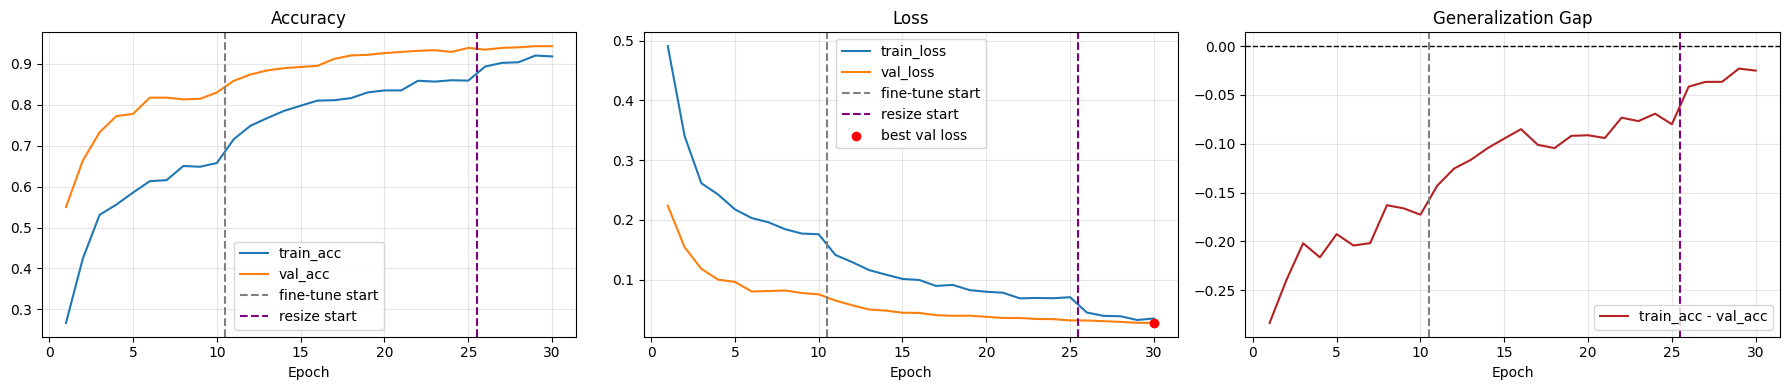

Best validation loss at epoch 30: 0.0276
Final train-val accuracy gap: -0.0251


In [9]:
print("STEP 6/13: Plot training curves and overfitting gap")

def merge_histories(history_objects):
    merged = {}
    for hist_obj in history_objects:
        if hist_obj is None:
            continue
        for key, values in hist_obj.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

history_objects = [history_head, history_fine]
if history_resize is not None:
    history_objects.append(history_resize)

hist = merge_histories(history_objects)
epochs = range(1, len(hist["loss"]) + 1)

phase_boundary_fine = len(history_head.history["loss"])
phase_boundary_resize = phase_boundary_fine + len(history_fine.history["loss"])

train_acc = np.array(hist["accuracy"])
val_acc = np.array(hist["val_accuracy"])
acc_gap = train_acc - val_acc

best_epoch = int(np.argmin(hist["val_loss"])) + 1
best_val_loss = float(np.min(hist["val_loss"]))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(epochs, hist["accuracy"], label="train_acc")
ax1.plot(epochs, hist["val_accuracy"], label="val_acc")
ax1.axvline(phase_boundary_fine + 0.5, linestyle="--", color="gray", label="fine-tune start")
if history_resize is not None:
    ax1.axvline(phase_boundary_resize + 0.5, linestyle="--", color="purple", label="resize start")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, hist["loss"], label="train_loss")
ax2.plot(epochs, hist["val_loss"], label="val_loss")
ax2.axvline(phase_boundary_fine + 0.5, linestyle="--", color="gray", label="fine-tune start")
if history_resize is not None:
    ax2.axvline(phase_boundary_resize + 0.5, linestyle="--", color="purple", label="resize start")
ax2.scatter([best_epoch], [best_val_loss], color="red", zorder=5, label="best val loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(alpha=0.3)

ax3.plot(epochs, acc_gap, color="firebrick", label="train_acc - val_acc")
ax3.axhline(0.0, linestyle="--", color="black", linewidth=1)
ax3.axvline(phase_boundary_fine + 0.5, linestyle="--", color="gray")
if history_resize is not None:
    ax3.axvline(phase_boundary_resize + 0.5, linestyle="--", color="purple")
ax3.set_title("Generalization Gap")
ax3.set_xlabel("Epoch")
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation loss at epoch {best_epoch}: {best_val_loss:.4f}")
print(f"Final train-val accuracy gap: {acc_gap[-1]:.4f}")

### Validation Diagnostics and Strategy Selection (Bias-Aware)

**Working:** Evaluates the best checkpoint on validation only, compares single vs TTA, optionally tests a multi-backbone ensemble, and selects one final inference strategy.

**Function:** Maximizes final test reliability by choosing all decision settings on validation before touching the test split.

STEP 7/13: Validation diagnostics + strategy selection (single/TTA/ensemble)
Validation (keras) -> loss: 0.0276, acc: 94.34%, top2: 98.02%

Validation (single)
  Accuracy           : 94.34%
  Balanced Accuracy  : 94.93%
  Macro Precision    : 0.9452
  Macro Recall       : 0.9493
  Macro F1           : 0.9460
  Weighted F1        : 0.9435
  Top-2 Accuracy     : 98.02%
  Log Loss           : 0.1972
  ECE (10 bins)      : 0.0378
  ROC-AUC (macro OVR): 0.9966

Validation (TTA x3)
  Accuracy           : 95.90%
  Balanced Accuracy  : 96.36%
  Macro Precision    : 0.9609
  Macro Recall       : 0.9636
  Macro F1           : 0.9611
  Weighted F1        : 0.9589
  Top-2 Accuracy     : 99.29%
  Log Loss           : 0.1446
  ECE (10 bins)      : 0.0415
  ROC-AUC (macro OVR): 0.9980

Evaluating optional backbone ensemble on validation...
  Skipped ensemble member cotton_best_efficientnetv2b0.keras: Input 0 with name 'input_image' of layer 'cotton_efficientnetv2b0' is incompatible with the layer: ex

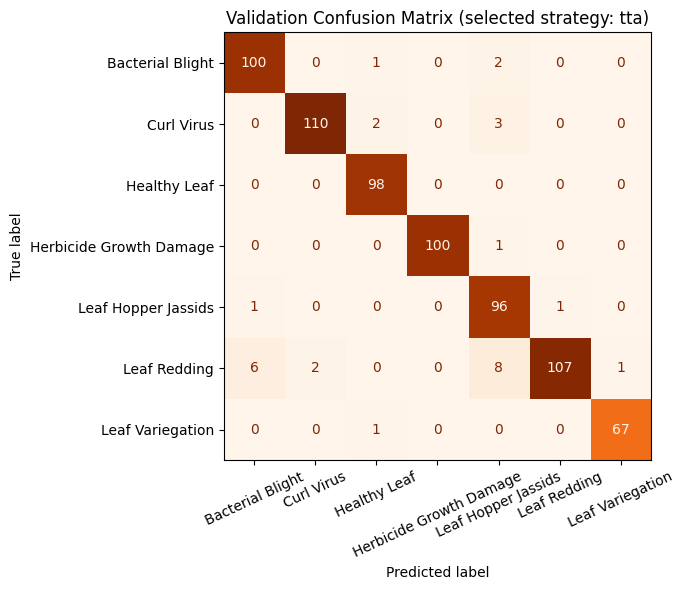


Top validation confusion pairs (true -> predicted):
  Leaf Redding -> Leaf Hopper Jassids: 8
  Leaf Redding -> Bacterial Blight: 6
  Curl Virus -> Leaf Hopper Jassids: 3
  Curl Virus -> Healthy Leaf: 2
  Leaf Redding -> Curl Virus: 2


In [10]:
print("STEP 7/13: Validation diagnostics + strategy selection (single/TTA/ensemble)")

best_model = keras.models.load_model(CKPT_PATH, compile=False)
compile_model(best_model, learning_rate=LR_FINE)

val_metrics_keras = best_model.evaluate(val_ds, verbose=0, return_dict=True)
print(
    f"Validation (keras) -> loss: {val_metrics_keras['loss']:.4f}, "
    f"acc: {val_metrics_keras['accuracy']*100:.2f}%, "
    f"top2: {val_metrics_keras['top2_acc']*100:.2f}%"
 )

y_true_val = []
for _, y in val_raw:
    y_true_val.extend(np.argmax(y.numpy(), axis=1))
y_true_val = np.array(y_true_val)

def expected_calibration_error(y_true_idx, y_prob, n_bins=10):
    conf = np.max(y_prob, axis=1)
    pred = np.argmax(y_prob, axis=1)
    acc = (pred == y_true_idx).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi) if i < n_bins - 1 else (conf >= lo) & (conf <= hi)
        if np.any(mask):
            ece += np.mean(mask) * abs(np.mean(acc[mask]) - np.mean(conf[mask]))
    return float(ece)

def summarize_probs(y_true_idx, y_prob, class_names, title):
    y_pred_idx = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_true_idx, y_pred_idx)
    bal_acc = balanced_accuracy_score(y_true_idx, y_pred_idx)
    f1_macro = f1_score(y_true_idx, y_pred_idx, average="macro")
    f1_weighted = f1_score(y_true_idx, y_pred_idx, average="weighted")
    top2 = top_k_accuracy_score(
        y_true_idx,
        y_prob,
        k=min(2, y_prob.shape[1]),
        labels=np.arange(y_prob.shape[1]),
    )
    nll = log_loss(y_true_idx, y_prob, labels=np.arange(y_prob.shape[1]))
    p_macro, r_macro, _, _ = precision_recall_fscore_support(
        y_true_idx, y_pred_idx, average="macro", zero_division=0
    )
    ece = expected_calibration_error(y_true_idx, y_prob, n_bins=10)

    try:
        auc_ovr = roc_auc_score(y_true_idx, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc_ovr = np.nan

    print(f"\n{title}")
    print(f"  Accuracy           : {acc*100:.2f}%")
    print(f"  Balanced Accuracy  : {bal_acc*100:.2f}%")
    print(f"  Macro Precision    : {p_macro:.4f}")
    print(f"  Macro Recall       : {r_macro:.4f}")
    print(f"  Macro F1           : {f1_macro:.4f}")
    print(f"  Weighted F1        : {f1_weighted:.4f}")
    print(f"  Top-2 Accuracy     : {top2*100:.2f}%")
    print(f"  Log Loss           : {nll:.4f}")
    print(f"  ECE (10 bins)      : {ece:.4f}")
    if np.isfinite(auc_ovr):
        print(f"  ROC-AUC (macro OVR): {auc_ovr:.4f}")

    return {
        "y_pred": y_pred_idx,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "top2": top2,
        "log_loss": nll,
        "ece": ece,
        "auc_ovr_macro": auc_ovr,
    }

def tta_predict_dataset(model, raw_dataset, augmentation_layer, rounds=3):
    probs = []
    for x_batch, _ in raw_dataset:
        x_batch = tf.cast(x_batch, tf.float32)
        round_preds = []
        for _ in range(rounds):
            aug = augmentation_layer(x_batch, training=True)
            aug = preprocess_input(aug)
            round_preds.append(model(aug, training=False).numpy())
        probs.append(np.mean(np.stack(round_preds, axis=0), axis=0))
    return np.concatenate(probs, axis=0)

def predict_probabilities(model, processed_dataset, raw_dataset, eval_mode, rounds, augmentation_layer):
    if eval_mode == "tta" and rounds > 1:
        return tta_predict_dataset(model, raw_dataset, augmentation_layer, rounds=rounds)
    return model.predict(processed_dataset, verbose=0)

y_prob_val_single = predict_probabilities(
    best_model,
    val_ds,
    val_raw,
    eval_mode="single",
    rounds=TTA_ROUNDS,
    augmentation_layer=data_augmentation,
 )
summary_val_single = summarize_probs(y_true_val, y_prob_val_single, class_names, title="Validation (single)")

summary_val_tta = None
if TTA_ROUNDS > 1:
    y_prob_val_tta = predict_probabilities(
        best_model,
        val_ds,
        val_raw,
        eval_mode="tta",
        rounds=TTA_ROUNDS,
        augmentation_layer=data_augmentation,
    )
    summary_val_tta = summarize_probs(
        y_true_val,
        y_prob_val_tta,
        class_names,
        title=f"Validation (TTA x{TTA_ROUNDS})",
    )

if summary_val_tta is not None and summary_val_tta["macro_f1"] > summary_val_single["macro_f1"]:
    SELECTED_EVAL_MODE = "tta"
    val_selected = summary_val_tta
else:
    SELECTED_EVAL_MODE = "single"
    val_selected = summary_val_single

USE_ENSEMBLE_FOR_FINAL = False
ENSEMBLE_MEMBER_PATHS = [str(CKPT_PATH)]
summary_val_ensemble = None

if ENABLE_BACKBONE_ENSEMBLE:
    candidate_paths = [Path(p) for p in ENSEMBLE_BACKBONE_PATHS if Path(p).exists()]
    if candidate_paths:
        print("\nEvaluating optional backbone ensemble on validation...")
        ensemble_probs = [
            predict_probabilities(
                best_model,
                val_ds,
                val_raw,
                eval_mode=SELECTED_EVAL_MODE,
                rounds=TTA_ROUNDS,
                augmentation_layer=data_augmentation,
            )
        ]
        member_paths = [str(CKPT_PATH)]

        for member_path in candidate_paths:
            try:
                member_model = keras.models.load_model(member_path, compile=False)
                compile_model(member_model, learning_rate=LR_FINE)
                member_prob = predict_probabilities(
                    member_model,
                    val_ds,
                    val_raw,
                    eval_mode=SELECTED_EVAL_MODE,
                    rounds=TTA_ROUNDS,
                    augmentation_layer=data_augmentation,
                )
                ensemble_probs.append(member_prob)
                member_paths.append(str(member_path))
                print(f"  Added ensemble member: {member_path.name}")
            except Exception as exc:
                print(f"  Skipped ensemble member {member_path.name}: {exc}")

        if len(ensemble_probs) > 1:
            y_prob_val_ensemble = np.mean(np.stack(ensemble_probs, axis=0), axis=0)
            summary_val_ensemble = summarize_probs(
                y_true_val,
                y_prob_val_ensemble,
                class_names,
                title=f"Validation ensemble ({len(ensemble_probs)} models, mode={SELECTED_EVAL_MODE})",
            )
            if summary_val_ensemble["macro_f1"] > val_selected["macro_f1"]:
                USE_ENSEMBLE_FOR_FINAL = True
                ENSEMBLE_MEMBER_PATHS = member_paths
                val_selected = summary_val_ensemble

if USE_ENSEMBLE_FOR_FINAL:
    print(
        f"\nSelected final inference strategy from validation: "
        f"{SELECTED_EVAL_MODE} + ensemble ({len(ENSEMBLE_MEMBER_PATHS)} models)"
    )
else:
    print(f"\nSelected final inference strategy from validation: {SELECTED_EVAL_MODE} (single backbone)")

print("\nClassification Report (Validation, selected strategy):")
print(
    classification_report(
        y_true_val,
        val_selected["y_pred"],
        labels=np.arange(len(class_names)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
 )

cm = confusion_matrix(y_true_val, val_selected["y_pred"], labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Oranges", xticks_rotation=25, colorbar=False, values_format="d")
strategy_label = f"{SELECTED_EVAL_MODE}" + (f" + ens({len(ENSEMBLE_MEMBER_PATHS)})" if USE_ENSEMBLE_FOR_FINAL else "")
ax.set_title(f"Validation Confusion Matrix (selected strategy: {strategy_label})")
plt.tight_layout()
plt.show()

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
flat_idx = np.argsort(cm_no_diag.ravel())[::-1]

print("\nTop validation confusion pairs (true -> predicted):")
shown = 0
for idx in flat_idx:
    count = int(cm_no_diag.ravel()[idx])
    if count == 0:
        break
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    print(f"  {class_names[i]} -> {class_names[j]}: {count}")
    shown += 1
    if shown == 5:
        break
if shown == 0:
    print("  None")

### Final Untouched Test Evaluation

**Working:** Applies the validation-selected inference strategy (single/TTA/optional ensemble), runs one final untouched test pass, computes bootstrap confidence intervals, and saves artifacts.

**Function:** Preserves evaluation integrity while reporting final performance with calibrated uncertainty and strategy traceability.

STEP 8/13: Final untouched test evaluation + save artifacts

Test (final, strategy=tta)
  Accuracy           : 96.03%
  Balanced Accuracy  : 96.39%
  Macro Precision    : 0.9633
  Macro Recall       : 0.9639
  Macro F1           : 0.9630
  Weighted F1        : 0.9605
  Top-2 Accuracy     : 99.15%
  Log Loss           : 0.1381
  ECE (10 bins)      : 0.0390
  ROC-AUC (macro OVR): 0.9984

Classification Report (Test):
                         precision    recall  f1-score   support

       Bacterial Blight     0.9320    0.9412    0.9366       102
             Curl Virus     0.9492    0.9739    0.9614       115
           Healthy Leaf     1.0000    0.9796    0.9897        98
Herbicide Growth Damage     1.0000    0.9802    0.9900       101
    Leaf Hopper Jassids     0.8796    0.9694    0.9223        98
           Leaf Redding     0.9825    0.9032    0.9412       124
       Leaf Variegation     1.0000    1.0000    1.0000        67

               accuracy                         0.9603     

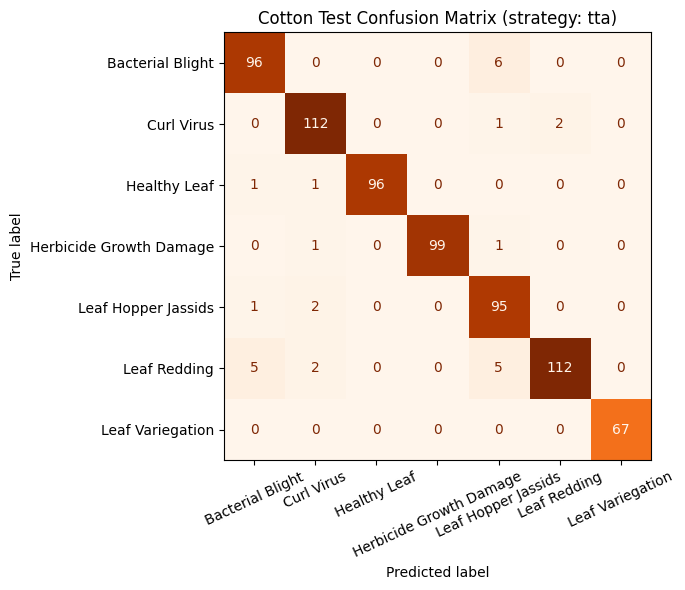

Accuracy 95% CI: [0.9447, 0.9745]
Macro-F1 95% CI: [0.9498, 0.9755]
Saved final model: /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_final_efficientnetv2s.keras
Saved class names: /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_class_names.json
Saved test report: /home/mohitmehta60/Desktop/Project/Minor Project/saved_models/cotton_final_test_report.json


In [11]:
print("STEP 8/13: Final untouched test evaluation + save artifacts")

if "SELECTED_EVAL_MODE" not in globals():
    SELECTED_EVAL_MODE = "single"
    print("SELECTED_EVAL_MODE not found. Defaulting to single-pass inference.")

if "USE_ENSEMBLE_FOR_FINAL" not in globals():
    USE_ENSEMBLE_FOR_FINAL = False

if "ENSEMBLE_MEMBER_PATHS" not in globals() or not ENSEMBLE_MEMBER_PATHS:
    ENSEMBLE_MEMBER_PATHS = [str(CKPT_PATH)]

if "best_model" not in globals():
    best_model = keras.models.load_model(CKPT_PATH, compile=False)
    compile_model(best_model, learning_rate=LR_FINE)

if "predict_probabilities" not in globals():
    def tta_predict_dataset(model, raw_dataset, augmentation_layer, rounds=3):
        probs = []
        for x_batch, _ in raw_dataset:
            x_batch = tf.cast(x_batch, tf.float32)
            round_preds = []
            for _ in range(rounds):
                aug = augmentation_layer(x_batch, training=True)
                aug = preprocess_input(aug)
                round_preds.append(model(aug, training=False).numpy())
            probs.append(np.mean(np.stack(round_preds, axis=0), axis=0))
        return np.concatenate(probs, axis=0)

    def predict_probabilities(model, processed_dataset, raw_dataset, eval_mode, rounds, augmentation_layer):
        if eval_mode == "tta" and rounds > 1:
            return tta_predict_dataset(model, raw_dataset, augmentation_layer, rounds=rounds)
        return model.predict(processed_dataset, verbose=0)

def bootstrap_ci(y_true_idx, y_pred_idx, metric_fn, rounds=1000, conf_level=0.95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true_idx)
    vals = []
    for _ in range(rounds):
        idx = rng.integers(0, n, size=n)
        vals.append(metric_fn(y_true_idx[idx], y_pred_idx[idx]))
    alpha = 1.0 - conf_level
    lo = float(np.percentile(vals, 100 * (alpha / 2.0)))
    hi = float(np.percentile(vals, 100 * (1.0 - alpha / 2.0)))
    return lo, hi

y_true_test = []
for _, y in test_raw:
    y_true_test.extend(np.argmax(y.numpy(), axis=1))
y_true_test = np.array(y_true_test)

def load_inference_member(model_path: Path):
    mdl = keras.models.load_model(model_path, compile=False)
    compile_model(mdl, learning_rate=LR_FINE)
    return mdl

if USE_ENSEMBLE_FOR_FINAL and len(ENSEMBLE_MEMBER_PATHS) > 1:
    probs_members = []
    valid_member_paths = []

    for model_path_str in ENSEMBLE_MEMBER_PATHS:
        model_path = Path(model_path_str)
        if not model_path.exists():
            print(f"Skipping missing ensemble member: {model_path}")
            continue

        if model_path.resolve() == CKPT_PATH.resolve():
            member_model = best_model
        else:
            member_model = load_inference_member(model_path)

        member_prob = predict_probabilities(
            member_model,
            test_ds,
            test_raw,
            eval_mode=SELECTED_EVAL_MODE,
            rounds=TTA_ROUNDS,
            augmentation_layer=data_augmentation,
        )
        probs_members.append(member_prob)
        valid_member_paths.append(str(model_path))

    if len(probs_members) >= 2:
        y_prob_test = np.mean(np.stack(probs_members, axis=0), axis=0)
        ENSEMBLE_MEMBER_PATHS = valid_member_paths
        FINAL_INFERENCE_STRATEGY = f"{SELECTED_EVAL_MODE}+ensemble({len(probs_members)})"
    else:
        USE_ENSEMBLE_FOR_FINAL = False
        y_prob_test = predict_probabilities(
            best_model,
            test_ds,
            test_raw,
            eval_mode=SELECTED_EVAL_MODE,
            rounds=TTA_ROUNDS,
            augmentation_layer=data_augmentation,
        )
        FINAL_INFERENCE_STRATEGY = SELECTED_EVAL_MODE
else:
    y_prob_test = predict_probabilities(
        best_model,
        test_ds,
        test_raw,
        eval_mode=SELECTED_EVAL_MODE,
        rounds=TTA_ROUNDS,
        augmentation_layer=data_augmentation,
    )
    FINAL_INFERENCE_STRATEGY = SELECTED_EVAL_MODE

summary_test = summarize_probs(
    y_true_test,
    y_prob_test,
    class_names,
    title=f"Test (final, strategy={FINAL_INFERENCE_STRATEGY})",
 )

print("\nClassification Report (Test):")
print(
    classification_report(
        y_true_test,
        summary_test["y_pred"],
        labels=np.arange(len(class_names)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
 )

cm_test = confusion_matrix(y_true_test, summary_test["y_pred"], labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(ax=ax, cmap="Oranges", xticks_rotation=25, colorbar=False, values_format="d")
ax.set_title(f"Cotton Test Confusion Matrix (strategy: {FINAL_INFERENCE_STRATEGY})")
plt.tight_layout()
plt.show()

acc_lo, acc_hi = bootstrap_ci(
    y_true_test,
    summary_test["y_pred"],
    metric_fn=lambda yt, yp: accuracy_score(yt, yp),
    rounds=BOOTSTRAP_ROUNDS,
    conf_level=CONFIDENCE_LEVEL,
    seed=SEED,
 )
f1_lo, f1_hi = bootstrap_ci(
    y_true_test,
    summary_test["y_pred"],
    metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro"),
    rounds=BOOTSTRAP_ROUNDS,
    conf_level=CONFIDENCE_LEVEL,
    seed=SEED + 1,
 )

print(f"Accuracy {int(CONFIDENCE_LEVEL * 100)}% CI: [{acc_lo:.4f}, {acc_hi:.4f}]")
print(f"Macro-F1 {int(CONFIDENCE_LEVEL * 100)}% CI: [{f1_lo:.4f}, {f1_hi:.4f}]")

FINAL_MODEL_PATH = MODELS_DIR / f"cotton_final_{BACKBONE_TAG}.keras"
CLASSES_PATH = MODELS_DIR / "cotton_class_names.json"
REPORT_PATH = MODELS_DIR / "cotton_final_test_report.json"

best_model.save(FINAL_MODEL_PATH)
with open(CLASSES_PATH, "w") as f:
    json.dump(class_names, f, indent=2)

report_payload = {
    "selected_eval_mode_from_validation": SELECTED_EVAL_MODE,
    "use_ensemble_for_final": bool(USE_ENSEMBLE_FOR_FINAL),
    "final_inference_strategy": FINAL_INFERENCE_STRATEGY,
    "ensemble_member_paths": ENSEMBLE_MEMBER_PATHS if USE_ENSEMBLE_FOR_FINAL else [str(CKPT_PATH)],
    "tta_rounds": int(TTA_ROUNDS),
    "test_metrics_sklearn": {
        "accuracy": float(summary_test["accuracy"]),
        "balanced_accuracy": float(summary_test["balanced_accuracy"]),
        "macro_f1": float(summary_test["macro_f1"]),
        "weighted_f1": float(summary_test["weighted_f1"]),
        "top2_accuracy": float(summary_test["top2"]),
        "log_loss": float(summary_test["log_loss"]),
        "ece": float(summary_test["ece"]),
        "auc_ovr_macro": (None if not np.isfinite(summary_test["auc_ovr_macro"]) else float(summary_test["auc_ovr_macro"])),
    },
    "confidence_intervals": {
        f"accuracy_{int(CONFIDENCE_LEVEL * 100)}ci": [acc_lo, acc_hi],
        f"macro_f1_{int(CONFIDENCE_LEVEL * 100)}ci": [f1_lo, f1_hi],
    },
    "notes": "Inference strategy selected using validation only. Test split evaluated once at the end.",
}
with open(REPORT_PATH, "w") as f:
    json.dump(report_payload, f, indent=2)

print("Saved final model:", FINAL_MODEL_PATH)
print("Saved class names:", CLASSES_PATH)
print("Saved test report:", REPORT_PATH)

### Optional Single-Image Inference

**Working:** Loads one validation image and visualizes top class confidences using the selected inference mode setup.

**Function:** Provides a practical sanity-check demo of how the tuned model behaves on an individual sample.

STEP 9/13 (optional): Single-image prediction demo (validation sample)


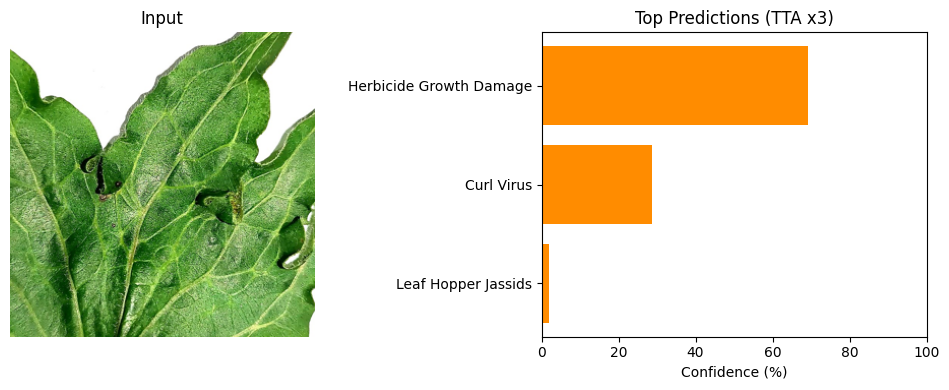

Sample path : /home/mohitmehta60/Desktop/Project/Minor Project/Datasets/cotton Dataset_clean_noleak/val/Herbicide Growth Damage/g0664_augmented_Herbicide Growth Damage0664_c15003dd.jpg
True class  : Herbicide Growth Damage
Prediction  : Herbicide Growth Damage (69.14%)


In [12]:
print("STEP 9/13 (optional): Single-image prediction demo (validation sample)")

if "SELECTED_EVAL_MODE" not in globals():
    SELECTED_EVAL_MODE = "single"

if "best_model" not in globals():
    best_model = keras.models.load_model(CKPT_PATH, compile=False)
    compile_model(best_model, learning_rate=LR_FINE)

def predict_single_image(image_path: str, model, class_names, img_size=(224, 224), top_k=3, tta_rounds=1):
    img = Image.open(image_path).convert("RGB").resize(img_size)
    arr = np.array(img, dtype=np.float32)
    batch = tf.convert_to_tensor(np.expand_dims(arr, axis=0), dtype=tf.float32)

    preds = []
    for _ in range(max(1, tta_rounds)):
        aug = data_augmentation(batch, training=True) if tta_rounds > 1 else batch
        aug = preprocess_input(aug)
        preds.append(model(aug, training=False).numpy())
    probs = np.mean(np.concatenate(preds, axis=0), axis=0)

    top_idx = np.argsort(probs)[::-1][:top_k]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input")

    plt.subplot(1, 2, 2)
    labels = [class_names[i] for i in top_idx]
    scores = [float(probs[i] * 100) for i in top_idx]
    plt.barh(labels[::-1], scores[::-1], color="darkorange")
    plt.xlim(0, 100)
    plt.xlabel("Confidence (%)")
    plt.title(f"Top Predictions (TTA x{max(1, tta_rounds)})")
    plt.tight_layout()
    plt.show()

    return class_names[top_idx[0]], float(probs[top_idx[0]])

sample_paths = (
    list(VAL_DIR.glob("*/*.jpg"))
    + list(VAL_DIR.glob("*/*.jpeg"))
    + list(VAL_DIR.glob("*/*.png"))
    + list(VAL_DIR.glob("*/*.webp"))
)
if not sample_paths:
    raise RuntimeError(f"No sample images found under {VAL_DIR}")

sample = str(random.choice(sample_paths))
true_class = Path(sample).parent.name
demo_tta_rounds = TTA_ROUNDS if SELECTED_EVAL_MODE == "tta" else 1
pred, conf = predict_single_image(
    sample,
    best_model,
    class_names,
    img_size=ACTIVE_IMAGE_SIZE,
    tta_rounds=demo_tta_rounds,
 )

print("Sample path :", sample)
print("True class  :", true_class)
print(f"Prediction  : {pred} ({conf*100:.2f}%)")

### Grad-CAM Visualization 

**Working:** Generates class-discriminative heatmaps for each cotton class using the trained model and overlays them on validation images.

**Function:** Improves interpretability by showing which leaf regions most influence model predictions across all cotton classes.

STEP 10/13 (optional): Grad-CAM gallery visualization (all cotton classes)


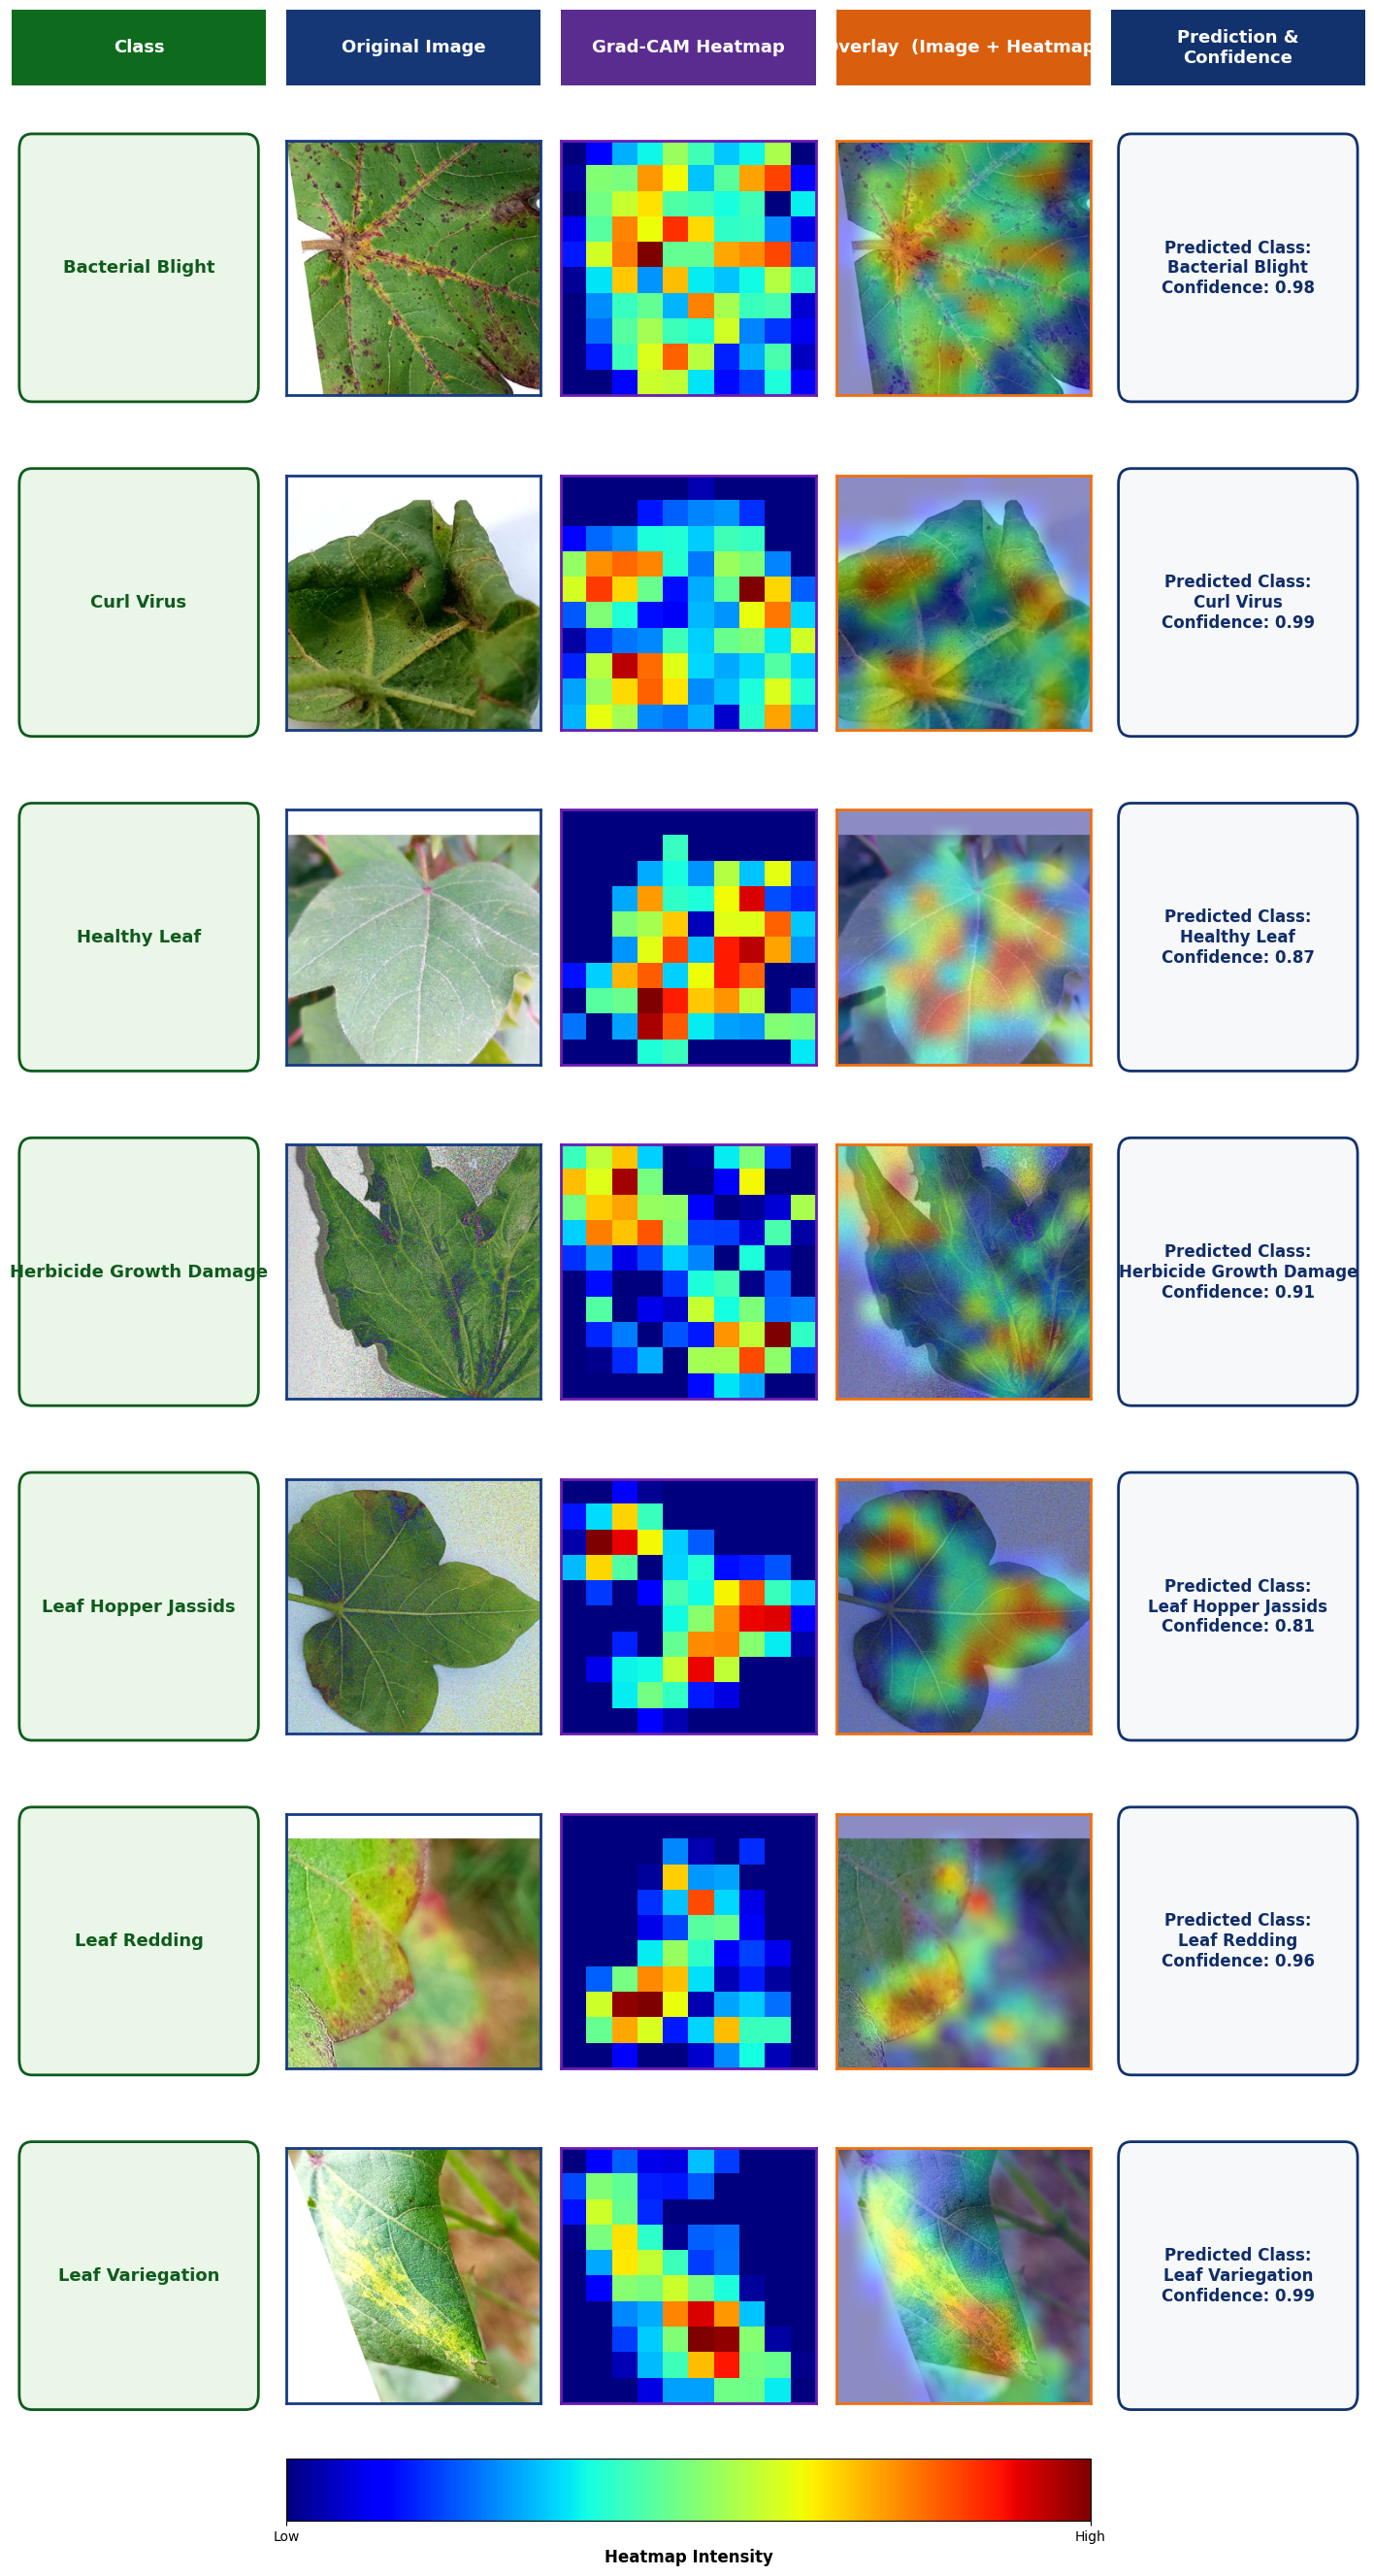

Grad-CAM panel generated for classes: ['Bacterial Blight', 'Curl Virus', 'Healthy Leaf', 'Herbicide Growth Damage', 'Leaf Hopper Jassids', 'Leaf Redding', 'Leaf Variegation']
Last conv layer used: top_conv


In [13]:
print("STEP 10/13 (optional): Grad-CAM gallery visualization (all cotton classes)")

import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.applications.efficientnet_v2 import preprocess_input
from PIL import Image
from pathlib import Path


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / "Datasets").exists() and (candidate / "saved_models").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing both 'Datasets' and 'saved_models'. "
        f"Current working directory: {cwd}"
    )


# Make this cell runnable even in a fresh kernel by resolving missing globals.
BASE_DIR = _find_project_root()
DATASETS_DIR = BASE_DIR / "Datasets"

if "ACTIVE_IMAGE_SIZE" in globals():
    IMG_SIZE = tuple(ACTIVE_IMAGE_SIZE)
elif "IMG_SIZE_FINE" in globals():
    IMG_SIZE = tuple(IMG_SIZE_FINE)
else:
    IMG_SIZE = (224, 224)

if "VAL_DIR" not in globals():
    VAL_DIR = DATASETS_DIR / "cotton Dataset_clean_noleak" / "val"

if "class_names" not in globals():
    classes_path = BASE_DIR / "saved_models" / "cotton_class_names.json"
    if classes_path.exists():
        with open(classes_path, "r") as f:
            class_names = json.load(f)
    else:
        class_names = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir()])

if "best_model" not in globals():
    if "BACKBONE_TAG" not in globals():
        BACKBONE_TAG = "efficientnetv2s"

    candidate_model_paths = [
        BASE_DIR / "saved_models" / f"cotton_final_{BACKBONE_TAG}.keras",
        BASE_DIR / "saved_models" / f"cotton_best_{BACKBONE_TAG}.keras",
        BASE_DIR / "saved_models" / "cotton_final_efficientnetv2s.keras",
        BASE_DIR / "saved_models" / "cotton_best_efficientnetv2s.keras",
    ]
    model_path = next((p for p in candidate_model_paths if p.exists()), None)
    if model_path is None:
        raise FileNotFoundError(
            f"No model checkpoint found at {BASE_DIR / 'saved_models'}. "
            "Run training/evaluation cells first or place a saved model there."
        )
    best_model = keras.models.load_model(model_path, compile=False)


def get_backbone_and_last_conv(model):
    backbone = None
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            backbone = layer
            break
    if backbone is None:
        raise ValueError("No nested backbone model found for Grad-CAM.")

    conv_name = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, layers.Conv2D):
            conv_name = layer.name
            break
    if conv_name is None:
        raise ValueError("No Conv2D layer found inside backbone for Grad-CAM.")

    backbone_with_conv = keras.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(conv_name).output, backbone.output],
    )

    backbone_idx = next(i for i, l in enumerate(model.layers) if l.name == backbone.name)
    head_layers = [l for l in model.layers[backbone_idx + 1:] if not isinstance(l, layers.InputLayer)]
    return conv_name, backbone_with_conv, head_layers


def load_image_for_gradcam(image_path, img_size):
    img = Image.open(image_path).convert("RGB").resize(img_size)
    arr = np.array(img, dtype=np.float32)
    batch = np.expand_dims(arr, axis=0)
    batch = preprocess_input(batch)
    return img, tf.convert_to_tensor(batch, dtype=tf.float32)


def make_gradcam_heatmap(preprocessed_batch, backbone_with_conv_model, head_layers, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, features = backbone_with_conv_model(preprocessed_batch, training=False)
        h = features
        for layer in head_layers:
            h = layer(h, training=False)
        preds = h

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    denom = tf.reduce_max(heatmap) + keras.backend.epsilon()
    heatmap = heatmap / denom

    probs = preds[0].numpy()
    return heatmap.numpy(), int(pred_index.numpy()), probs


def overlay_heatmap_on_image(pil_img, heatmap, alpha=0.45, cmap_name="jet"):
    heatmap_uint8 = np.uint8(255 * np.clip(heatmap, 0, 1))
    colormap = plt.get_cmap(cmap_name)
    color_map = colormap(np.arange(256))[:, :3]
    color_heatmap = color_map[heatmap_uint8]
    color_heatmap_img = Image.fromarray(np.uint8(color_heatmap * 255)).resize(pil_img.size)

    base = np.array(pil_img, dtype=np.float32)
    overlay = np.array(color_heatmap_img, dtype=np.float32)
    blended = np.clip((1 - alpha) * base + alpha * overlay, 0, 255).astype(np.uint8)
    return blended


conv_layer_name, backbone_with_conv_model, head_layers = get_backbone_and_last_conv(best_model)

# Include all cotton classes in the Grad-CAM panel.
TARGET_CLASSES = [
    "Bacterial Blight",
    "Curl Virus",
    "Healthy Leaf",
    "Herbicide Growth Damage",
    "Leaf Hopper Jassids",
    "Leaf Redding",
    "Leaf Variegation",
]
TARGET_CLASSES = [c for c in TARGET_CLASSES if (VAL_DIR / c).exists()]

if not TARGET_CLASSES:
    TARGET_CLASSES = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir()])

rows = []
skipped_classes = []
for cls in TARGET_CLASSES:
    candidates = (
        list((VAL_DIR / cls).glob("*.jpg"))
        + list((VAL_DIR / cls).glob("*.jpeg"))
        + list((VAL_DIR / cls).glob("*.png"))
        + list((VAL_DIR / cls).glob("*.webp"))
    )
    if not candidates:
        skipped_classes.append(cls)
        continue

    image_path = str(random.choice(candidates))
    pil_img, batch_input = load_image_for_gradcam(image_path, IMG_SIZE)
    heatmap, pred_idx, probs = make_gradcam_heatmap(batch_input, backbone_with_conv_model, head_layers, pred_index=None)
    overlay_img = overlay_heatmap_on_image(pil_img, heatmap, alpha=0.45, cmap_name="jet")

    conf = float(np.max(probs))
    pred_label = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)

    rows.append({
        "class_key": cls,
        "display_class": cls,
        "image_path": image_path,
        "orig": np.array(pil_img),
        "heatmap": heatmap,
        "overlay": overlay_img,
        "pred": pred_label,
        "conf": conf,
    })

if skipped_classes:
    print("Skipped classes with no validation images:", skipped_classes)

if not rows:
    raise RuntimeError(f"No images found for TARGET_CLASSES in {VAL_DIR}")

n = len(rows)
fig = plt.figure(figsize=(18, 4.2 * (n + 1)))
gs = fig.add_gridspec(nrows=n + 2, ncols=5, height_ratios=[0.55] + [2.2] * n + [0.45], hspace=0.12, wspace=0.08)

header_titles = [
    "Class",
    "Original Image",
    "Grad-CAM Heatmap",
    "Overlay  (Image + Heatmap)",
    "Prediction &\nConfidence",
]
header_colors = ["#0E6B1D", "#153776", "#5B2C90", "#D95E0E", "#12326E"]

for c in range(5):
    ax = fig.add_subplot(gs[0, c])
    ax.set_facecolor(header_colors[c])
    ax.text(
        0.5, 0.5, header_titles[c],
        ha="center", va="center", color="white", fontsize=13, fontweight="bold"
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

for r, item in enumerate(rows, start=1):
    ax0 = fig.add_subplot(gs[r, 0])
    ax0.set_axis_off()
    ax0.text(
        0.5, 0.5, item["display_class"],
        ha="center", va="center",
        fontsize=13, color="#0F5B1D", fontweight="bold"
    )
    ax0.add_patch(
        mpl.patches.FancyBboxPatch(
            (0.05, 0.08), 0.90, 0.84, boxstyle="round,pad=0.02,rounding_size=0.05",
            edgecolor="#0F5B1D", facecolor="#EAF6E8", linewidth=2, transform=ax0.transAxes
        )
    )

    ax1 = fig.add_subplot(gs[r, 1])
    ax1.imshow(item["orig"])
    ax1.set_xticks([])
    ax1.set_yticks([])
    for sp in ax1.spines.values():
        sp.set_linewidth(2)
        sp.set_edgecolor("#173A84")

    ax2 = fig.add_subplot(gs[r, 2])
    ax2.imshow(item["heatmap"], cmap="jet")
    ax2.set_xticks([])
    ax2.set_yticks([])
    for sp in ax2.spines.values():
        sp.set_linewidth(2)
        sp.set_edgecolor("#6A1CB2")

    ax3 = fig.add_subplot(gs[r, 3])
    ax3.imshow(item["overlay"])
    ax3.set_xticks([])
    ax3.set_yticks([])
    for sp in ax3.spines.values():
        sp.set_linewidth(2)
        sp.set_edgecolor("#F07110")

    ax4 = fig.add_subplot(gs[r, 4])
    ax4.set_axis_off()
    conf_text = f"Predicted Class:\n{item['pred']}\nConfidence: {item['conf']:.2f}"
    ax4.text(
        0.5, 0.5, conf_text,
        ha="center", va="center",
        fontsize=12, color="#102D68", fontweight="bold"
    )
    ax4.add_patch(
        mpl.patches.FancyBboxPatch(
            (0.05, 0.08), 0.90, 0.84, boxstyle="round,pad=0.02,rounding_size=0.05",
            edgecolor="#12326E", facecolor="#F7F8FA", linewidth=2, transform=ax4.transAxes
        )
    )

cax = fig.add_subplot(gs[n + 1, 1:4])
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
sm = mpl.cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Heatmap Intensity", fontsize=12, fontweight="bold")
cb.set_ticks([0, 1])
cb.set_ticklabels(["Low", "High"])

plt.show()

print("Grad-CAM panel generated for classes:", [x["class_key"] for x in rows])
print("Last conv layer used:", conv_layer_name)